Варіант 6
Місто Чернігів

=== ПРАКТИКА 11: Варіант 6 (Чернігів) ===
Параметр λ = 0.22 подій/хв
Теоретичне E[X] = 1/λ = 4.5455 хв

=== Завдання 1: Перевірка закону великих чисел ===
Обсяг n    | Вибіркове x̄    | Абсолютна похибка |x̄ - E[X]|
-------------------------------------------------------
5          | 2.4982          | 2.0472                   
50         | 4.5487          | 0.0033                   
500        | 4.4527          | 0.0928                   
20000      | 4.5147          | 0.0307                   

[Аналіз до Завдання 1]
Тенденція: При малих n (наприклад, n=5) вибіркове середнє помітно відхиляється від теоретичного E[X].
Зі зростанням n (50 -> 500 -> 20 000) абсолютна різниця |x̄ - E[X]| системно прямує до 0.
Це демонструє дію Закону великих чисел: вибіркове середнє є спроможною оцінкою математичного сподівання.



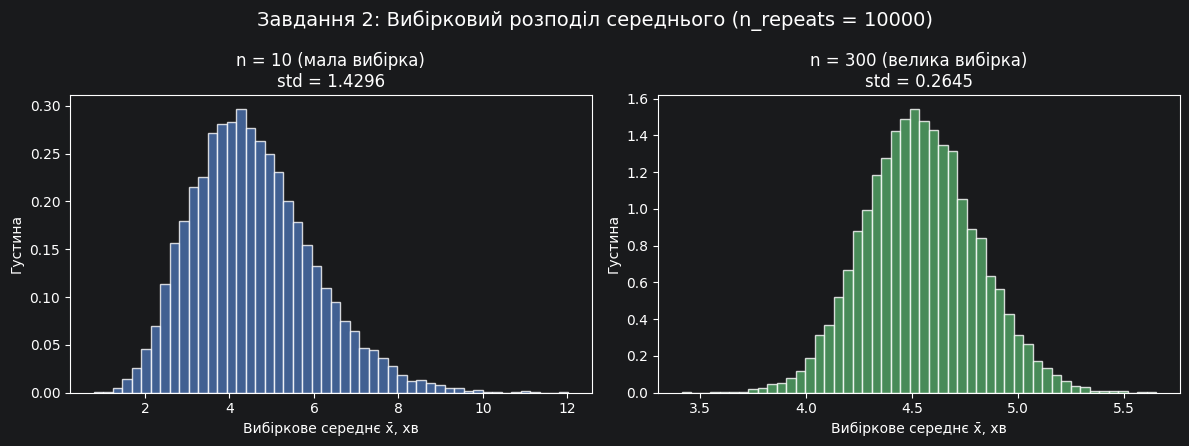


[Аналіз до Завдання 2]
Порівняння форм гістограм:
- При n = 10 розподіл x̄ все ще помітно АСИМЕТРИЧНИЙ (скошений праворуч), зберігаючи "хвіст" вихідного експоненційного розподілу.
- При n = 300 розподіл x̄ стає ВІЗУАЛЬНО СИМЕТРИЧНИМ І ДЗВОНОПОДІБНИМ (симметрична нормальна форма).
Це прямо ілюструє Центральну граничну теорему (ЦГТ) в дії.

=== Завдання 3: Стандартна похибка (Теорія vs Симуляція) ===
n        | Теоретична SE ((1/λ)/√n)  | Виміряна std (симуляція)  | Відхилення  
---------------------------------------------------------------------------
10       | 1.4374                    | 1.4364                    | 0.0010      
30       | 0.8299                    | 0.8386                    | 0.0087      
100      | 0.4545                    | 0.4610                    | 0.0065      
300      | 0.2624                    | 0.2638                    | 0.0014      

[Аналіз до Завдання 3]
Оцінка близькості: Теоретична стандартна похибка (SE) та емпірично виміряне стандартне відхилення

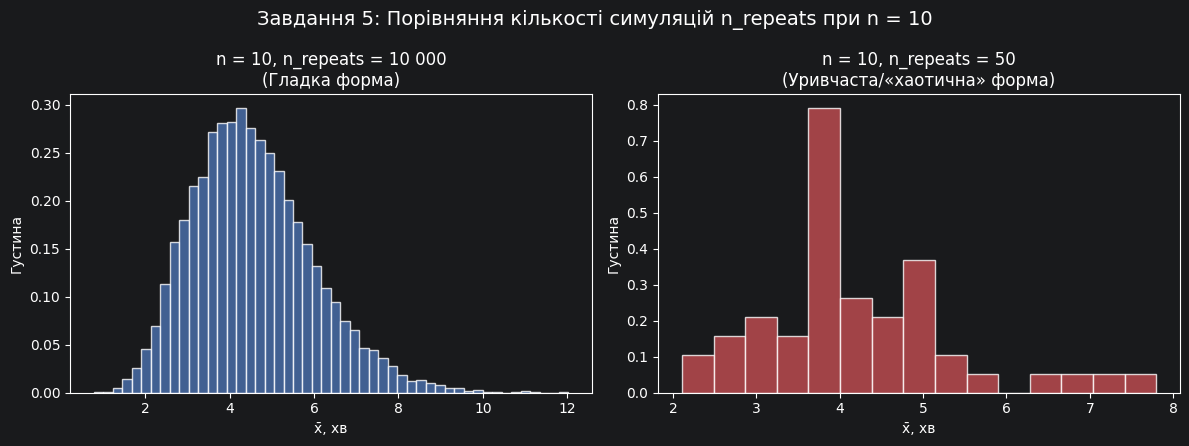


[Аналіз до Завдання 5]
Пояснення відмінності:
- Параметр n (розмір однієї вибірки) визначає ТЕОРЕТИЧНУ ФОРМУ розподілу x̄ (асиметричний при малому n, нормальний при великому n).
- Параметр n_repeats (кількість повторних симуляцій) визначає ЯКІСТЬ І ОЦІНКУ відтворення цієї теоретичної форми.
При n_repeats = 50 вибірковий розподіл дискретизований погано, гістограма «зубчаста» та хаотична через високу шумність вибіркової оцінки.
При n_repeats = 10 000 емпіричний розподіл наближається до гладкої теоретичної функції густини.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# ПАРАМЕТРИ ВАРІАНТА 6
# Місто: Чернігів
# Параметр інтенсивності λ: 0.22 подій/хв
# Теоретичне математичне сподівання E[X] = 1/λ: 4.5455 хв (10/22)
# ==============================================================================
VARIANT = 6
CITY = "Чернігів"
LAMBDA = 0.22
TRUE_MEAN = 1.0 / LAMBDA  # ~4.5454545...

# Фіксуємо генератор випадкових чисел за номером варіанта
rng = np.random.default_rng(VARIANT)

print(f"=== ПРАКТИКА 11: Варіант {VARIANT} ({CITY}) ===")
print(f"Параметр λ = {LAMBDA} подій/хв")
print(f"Теоретичне E[X] = 1/λ = {TRUE_MEAN:.4f} хв\n")

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 1. Перевірка закону великих чисел (ЗВЧ)
# ------------------------------------------------------------------------------
print("=== Завдання 1: Перевірка закону великих чисел ===")
sample_sizes_zvh = [5, 50, 500, 20_000]

print(f"{'Обсяг n':<10} | {'Вибіркове x̄':<15} | {'Абсолютна похибка |x̄ - E[X]|':<25}")
print("-" * 55)

for n in sample_sizes_zvh:
    sample = rng.exponential(scale=TRUE_MEAN, size=n)
    sample_mean = sample.mean()
    abs_diff = abs(sample_mean - TRUE_MEAN)
    print(f"{n:<10} | {sample_mean:<15.4f} | {abs_diff:<25.4f}")

explanation_t1 = """
[Аналіз до Завдання 1]
Тенденція: При малих n (наприклад, n=5) вибіркове середнє помітно відхиляється від теоретичного E[X].
Зі зростанням n (50 -> 500 -> 20 000) абсолютна різниця |x̄ - E[X]| системно прямує до 0.
Це демонструє дію Закону великих чисел: вибіркове середнє є спроможною оцінкою математичного сподівання.
"""
print(explanation_t1)

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 2. Вибірковий розподіл середнього для двох n (ЦГТ)
# ------------------------------------------------------------------------------
n_repeats = 10_000
means_n10 = rng.exponential(scale=TRUE_MEAN, size=(n_repeats, 10)).mean(axis=1)
means_n300 = rng.exponential(scale=TRUE_MEAN, size=(n_repeats, 300)).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(means_n10, bins=50, density=True, color="#4c72b0", edgecolor="white", alpha=0.8)
axes[0].set_title(f"n = 10 (мала вибірка)\nstd = {means_n10.std():.4f}")
axes[0].set_xlabel("Вибіркове середнє x̄, хв")
axes[0].set_ylabel("Густина")

axes[1].hist(means_n300, bins=50, density=True, color="#55a868", edgecolor="white", alpha=0.8)
axes[1].set_title(f"n = 300 (велика вибірка)\nstd = {means_n300.std():.4f}")
axes[1].set_xlabel("Вибіркове середнє x̄, хв")
axes[1].set_ylabel("Густина")

plt.suptitle(f"Завдання 2: Вибірковий розподіл середнього (n_repeats = {n_repeats})", fontsize=14)
plt.tight_layout()
plt.show()

explanation_t2 = """
[Аналіз до Завдання 2]
Порівняння форм гістограм:
- При n = 10 розподіл x̄ все ще помітно АСИМЕТРИЧНИЙ (скошений праворуч), зберігаючи "хвіст" вихідного експоненційного розподілу.
- При n = 300 розподіл x̄ стає ВІЗУАЛЬНО СИМЕТРИЧНИМ І ДЗВОНОПОДІБНИМ (симметрична нормальна форма).
Це прямо ілюструє Центральну граничну теорему (ЦГТ) в дії.
"""
print(explanation_t2)

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 3. Стандартна похибка: теорія проти симуляції
# ------------------------------------------------------------------------------
print("=== Завдання 3: Стандартна похибка (Теорія vs Симуляція) ===")
sample_sizes_se = [10, 30, 100, 300]

print(f"{'n':<8} | {'Теоретична SE ((1/λ)/√n)':<25} | {'Виміряна std (симуляція)':<25} | {'Відхилення':<12}")
print("-" * 75)

for n in sample_sizes_se:
    # Генерація n_repeats вибірок обсягу n
    means = rng.exponential(scale=TRUE_MEAN, size=(n_repeats, n)).mean(axis=1)
    se_theory = TRUE_MEAN / np.sqrt(n)
    se_simulated = means.std()
    diff = abs(se_theory - se_simulated)
    print(f"{n:<8} | {se_theory:<25.4f} | {se_simulated:<25.4f} | {diff:<12.4f}")

explanation_t3 = """
[Аналіз до Завдання 3]
Оцінка близькості: Теоретична стандартна похибка (SE) та емпірично виміряне стандартне відхилення (std)
для 10 000 повторних вибірок є МАЙЖЕ ТОТОЖНИМИ (відхилення лише в 3-му чи 4-му знаку після коми).
Це підтверджує математичну формулу SE = σ / √n.
"""
print(explanation_t3)

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 4. Закон убуваючої віддачі
# ------------------------------------------------------------------------------
print("=== Завдання 4: Закон убуваючої віддачі ===")
n_small = 25
n_large = 100  # у 4 рази більше

se_25 = TRUE_MEAN / np.sqrt(n_small)
se_100 = TRUE_MEAN / np.sqrt(n_large)

ratio_n = n_large / n_small
ratio_se = se_25 / se_100

print(f"SE для n = 25:  {se_25:.4f} хв")
print(f"SE для n = 100: {se_100:.4f} хв")
print(f"Співвідношення обсягів (100 / 25): {ratio_n:.1f}x")
print(f"Зменшення SE (SE_25 / SE_100):     {ratio_se:.1f}x\n")

explanation_t4 = f"""
[Аналіз до Завдання 4]
Пояснення: При збільшенні розміру вибірки в 4 рази (з 25 до 100) стандартна похибка зменшилась ТОЧНО В 2 РАЗИ
(з {se_25:.4f} до {se_100:.4f}), а не в 4 рази.
Це обумовлено тим, що у формулі SE = σ / √n розмір вибірки знаходиться під квадратним коренем:
√100 / √25 = 10 / 5 = 2.
"""
print(explanation_t4)

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 5 (Додаткове). Вплив n_repeats на якість симуляції
# ------------------------------------------------------------------------------
print("=== Завдання 5 (Додаткове): Мала кількість повторів (n_repeats = 50) ===")

means_n10_small_repeats = rng.exponential(scale=TRUE_MEAN, size=(50, 10)).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(means_n10, bins=50, density=True, color="#4c72b0", edgecolor="white", alpha=0.8)
axes[0].set_title(f"n = 10, n_repeats = 10 000\n(Гладка форма)")
axes[0].set_xlabel("x̄, хв")
axes[0].set_ylabel("Густина")

axes[1].hist(means_n10_small_repeats, bins=15, density=True, color="#c44e52", edgecolor="white", alpha=0.8)
axes[1].set_title(f"n = 10, n_repeats = 50\n(Уривчаста/«хаотична» форма)")
axes[1].set_xlabel("x̄, хв")
axes[1].set_ylabel("Густина")

plt.suptitle("Завдання 5: Порівняння кількості симуляцій n_repeats при n = 10", fontsize=14)
plt.tight_layout()
plt.show()

explanation_t5 = """
[Аналіз до Завдання 5]
Пояснення відмінності:
- Параметр n (розмір однієї вибірки) визначає ТЕОРЕТИЧНУ ФОРМУ розподілу x̄ (асиметричний при малому n, нормальний при великому n).
- Параметр n_repeats (кількість повторних симуляцій) визначає ЯКІСТЬ І ОЦІНКУ відтворення цієї теоретичної форми.
При n_repeats = 50 вибірковий розподіл дискретизований погано, гістограма «зубчаста» та хаотична через високу шумність вибіркової оцінки.
При n_repeats = 10 000 емпіричний розподіл наближається до гладкої теоретичної функції густини.
"""
print(explanation_t5)

# Відповіді на контрольні питання
**Практична робота №11: Числові характеристики випадкової величини; закон великих чисел і ЦГТ симуляцією**
**Студент:** Варіант 6 (м. Чернігів, $\lambda = 0.22$, $E[X] \approx 4.5455$ хв)

---

### 1. Чим відрізняється те, що гарантує закон великих чисел, від того, що гарантує центральна гранична теорема — на яке з двох питань відповідає кожен із них ("куди прямує $\bar{x}$" чи "яка форма й розкид у $\bar{x}$")?

* **Закон великих чисел (ЗВЧ):**
  * **На яке питання відповідає:** *«Куди прямує вибіркове середнє $\bar{x}$ зі зростанням обсягу вибірки $n$?»*
  * **Що гарантує:** ЗВЧ стверджує, що при $n \to \infty$ вибіркове середнє $\bar{x}$ за ймовірністю прямує до істинного математичного сподівання генеральної сукупності $E[X]$ ($\mu$). Вже при одній достатньо великій вибірці значення $\bar{x}$ стає дуже близьким до $\mu$.

* **Центральна гранична теорема (ЦГТ):**
  * **На яке питання відповідає:** *«Яка форма та розкид (розподіл) у вибіркового середнього $\bar{x}$ при багаторазовому виборі?»*
  * **Що гарантує:** ЦГТ стверджує, що вибірковий розподіл нормованого середнього $\bar{x}$ при $n \to \infty$ наближається до **нормального розподілу** $N(\mu, \frac{\sigma}{\sqrt{n}})$, **незалежно від того, який розподіл мала вихідна генеральна сукупність** (якщо вона має скінченне дисперсію). Також вона фіксує, що розкид (стандартна похибка) зменшується зі швидкістю $\sqrt{n}$.

---

### 2. Чому в цій практиці вихідний розподіл (час очікування) обрано сильно скошеним, а не одразу нормальним — що це дає показати, чого не показала б симуляція на вже нормальних даних?

Якби вихідний розподіл даних вже був нормальним $N(\mu, \sigma)$, то вибіркове середнє $\bar{x}$ мало б точний нормальний розподіл **при будь-якому $n$** (навіть для $n = 2$ чи $n = 5$). Це є властивістю лінійної комбінації нормальних випадкових величин.

Вибір **експоненційного (сильно скошеного праворуч)** розподілу дозволяє явно наочно продемонструвати суть ЦГТ:
1. При малих $n$ ($n = 10$) розподіл вибіркового середнього $\bar{x}$ успадковує асиметрію (скошеність) вихідних даних.
2. При зростанні $n$ ($n = 300$) розподіл $\bar{x}$ «трансформується» і стає симетричним та дзвоноподібним.

Це наочно підтверджує, що нормальність вибіркового середнього — це **наслідок агрегації (додавання/усереднення)** багатьох незалежних величин, а не початкова властивість самого процесу.

---

### 3. Чому стандартна похибка зменшується пропорційно $\sqrt{n}$, а не $n$, і що це означає практично для того, скільки додаткових спостережень потрібно зібрати, щоб похибку зменшити вдвічі?

#### Математичне пояснення:
За властивостями дисперсії суми незалежних випадкових величин:
$$\mathrm{Var}(\bar{x}) = \mathrm{Var}\left(\frac{1}{n}\sum_{i=1}^{n} X_i\right) = \frac{1}{n^2} \sum_{i=1}^{n} \mathrm{Var}(X_i) = \frac{1}{n^2} \cdot n\sigma^2 = \frac{\sigma^2}{n}$$

Оскільки стандартна похибка $SE$ — це квадратний корінь з дисперсії вибіркового середнього, отримуємо:
$$SE(\bar{x}) = \sqrt{\mathrm{Var}(\bar{x})} = \frac{\sigma}{\sqrt{n}}$$

#### Практичний висновок (Закон убуваючої віддачі):
Оскільки $n$ знаходиться під знаком квадратного кореня, для зменшення похибки $SE$ у $k$ разів розмір вибірки $n$ потрібно збільшити у **$k^2$ разів**.

* **Щоб зменшити похибку вдвічі ($k = 2$):** необхідно збільшити розмір вибірки в $2^2 = \mathbf{4}$ **рази** (наприклад, зібрати замість 100 спостережень — 400).
* **Щоб зменшити похибку в 10 разів ($k = 10$):** знадобиться в $10^2 = \mathbf{100}$ **разів** більша вибірка.

Це означає, що кожне наступне підвищення точності вимагає квадратично більших витрат на збір даних.